# Dynamic SOT using jaxinv (Type 3)

last update: 1/13 (2026) Hajime Kawahara
In this tutorial, we apply NonSLIP to the Type 3 Bayesian linear inverse problem solver from jaxinv to infer a dynamic map from monochromatic time-series data. The reference for this method is Kawahara and Masuda (2020).

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

Note: It is known that the current implementation does not work properly unless 64-bit mode is enabled.

In [2]:
from jax import config
config.update("jax_enable_x64", True)


In [3]:
import numpy as np
import healpy as hp
import matplotlib
from sot.core import sepmat
from sot.core import mvmap
from sot.core.weight import compute_omega
from sot.core.weight import compute_weight 



In [4]:
fontsize=16
matplotlib.rcParams.update({'font.size':fontsize})
np.random.seed(53)

#set geometry                                                               
inc=45.0/180.0*np.pi
Thetaeq=np.pi
zeta=23.4/180.0*np.pi
Pspin=23.9344699/24.0 #Pspin: a sidereal day                                
wspin=2*np.pi/Pspin
Porb=365.242190402
worb=2*np.pi/Porb                                                          \

Ni=1024
obst=np.linspace(0.0,Porb,Ni)

# test moving map                                                           
nside=16
npix=hp.nside2npix(nside)

No title or mismatch


  0%|          | 0/3 [00:00<?, ?it/s]

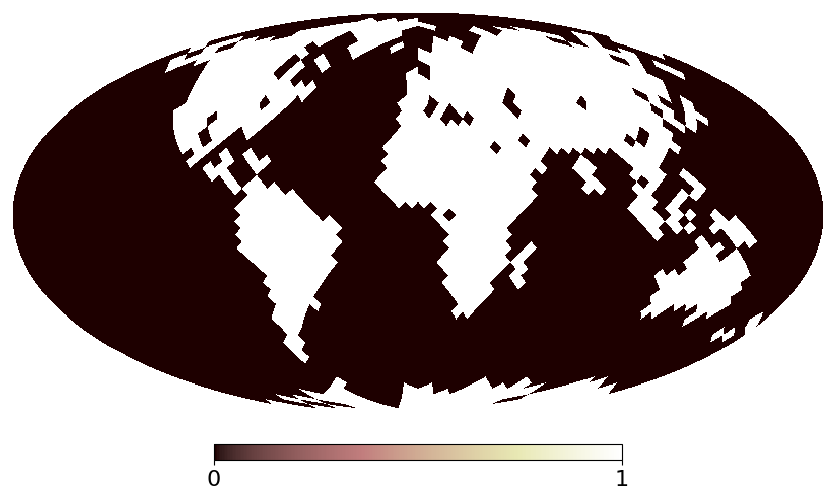

 33%|███▎      | 1/3 [00:00<00:00,  3.90it/s]

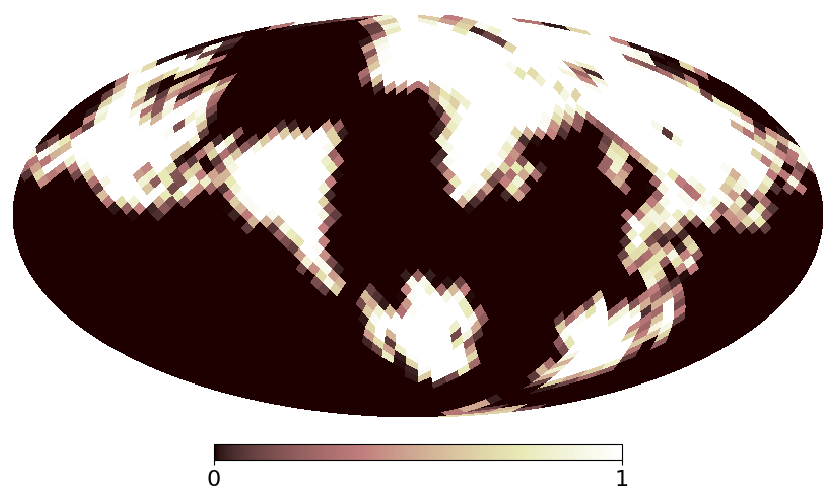

 67%|██████▋   | 2/3 [00:00<00:00,  5.23it/s]

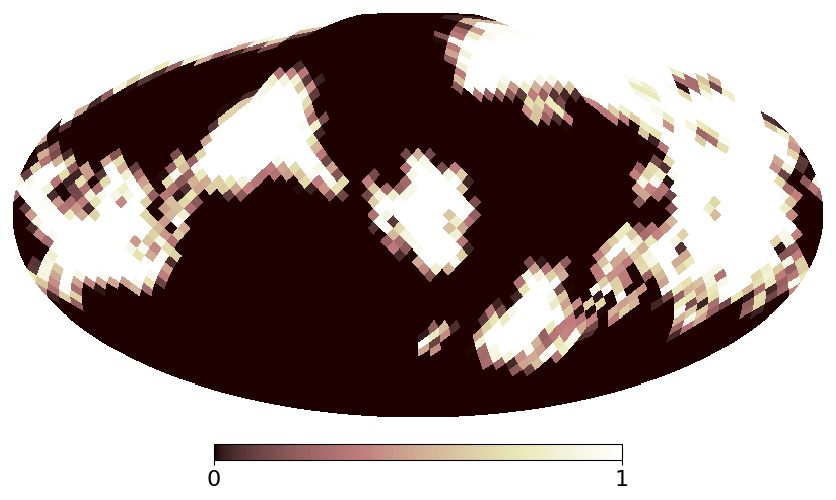

100%|██████████| 3/3 [00:00<00:00,  5.42it/s]


In [5]:
from sot.io.load_data import get_data_filepath
from sot.plot.plotdymap import plotseqmap
import healpy as hp
nside = 16
npix = hp.nside2npix(nside)
file_path = get_data_filepath("mockalbedo16.fits")
mmap = hp.read_map(file_path)

mask = mmap > 0.0
mmap[mask] = 1.0
movmap = mvmap.rotating_map(mmap, obst, rotthetamax=np.pi / 2.0)
frames=[0,int(Ni/2),Ni-1]
plotseqmap(movmap,frames,"map input","",vmin=0.0,vmax=1.0,zero=False,pdf=False,png=False,show=True)


In [7]:
import jax.numpy as jnp
from jaxinv.model.linear import type3
# geometric weight
Thetav = worb * obst
Phiv = np.mod(wspin * obst, 2 * np.pi)
omega = compute_omega(nside)
WI, WV = compute_weight(zeta, inc, Thetaeq, Thetav, Phiv, omega)
W = jnp.array(WV[:, :] * WI[:, :])
movmap = jnp.array(movmap)
# Light curve

#lc = jnp.sum(W * movmap, axis=1)
lc = type3(W, movmap)
noiselevel = 0.01
sigma = noiselevel * np.mean(lc)
noise = sigma * np.random.normal(0.0, 1.0, np.shape(lc))
lc = lc + noise

In [9]:
from numpyro.infer import MCMC, NUTS
import numpyro
import numpyro.distributions as dist
from jax import random
from sot.core import sepmat 
from jaxinv.bayes.gpkernel import rbf
from jaxinv.bayes.gpkernel import matern32
from jaxinv.bayes.meanmap import meanmap_inverse_type3
from jaxinv.bayes.weighted_kernel import grand_weighted_kernel_type3

In [10]:
Thetaeq = np.pi
zeta = 23.4 / 180.0 * np.pi
sep=sepmat.calc_sepmatrix(nside)

def model(y):
    #geometric weight
    cos_zeta = numpyro.sample('u', dist.Uniform(-1.0, 1.0))
    zeta = jnp.arccos(cos_zeta)
    numpyro.deterministic('zeta', zeta)
    Thetaeq = numpyro.sample('Thetaeq', dist.Uniform(0.0, 2*jnp.pi))
    WI, WV = compute_weight(zeta, inc, Thetaeq, Thetav, Phiv, omega)
    geometric_weight = jnp.array(WV[:, :] * WI[:, :])
    
    #GP kernel
    alpha = numpyro.sample('alpha', dist.Exponential(1.0))
    #gamma = numpyro.sample('gamma', dist.Exponential(1.0)) #takes much longer time
    gamma = 10.0 / 180.0 * np.pi 
    KS_RBF=alpha*rbf(sep, gamma)
    
    tau = 180.0
    dtime_matrix = obst - np.array([obst]).T
    KT_Mat32 = matern32(dtime_matrix, tau)


    #data noise
    sigma_d = numpyro.sample('sigma_d', dist.Exponential(1.0))
    #jitter = 1.e-6*jnp.eye(KS_RBF.shape[0]) #add a small jitter to Kernel_model_RBF if it's unstable
    kernel = sigma_d**2 * jnp.eye(len(y)) + grand_weighted_kernel_type3(geometric_weight, KS_RBF, KT_Mat32)  
    mu = jnp.zeros_like(y)
    numpyro.sample('y', dist.MultivariateNormal(mu, kernel), obs=y)

In [ ]:
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)
num_warmup, num_samples = 500, 1000
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples)
mcmc.run(rng_key_, y=lc)
mcmc.print_summary()

In [ ]:
import arviz
pararr = ["zeta", "Thetaeq", "alpha","sigma_d"]
arviz.plot_pair(
    arviz.from_numpyro(mcmc),
    kind="kde",
    divergences=False,
    marginals=True,
    var_names=pararr,
    reference_values={"zeta": zeta, "Thetaeq": Thetaeq, "sigma_d": sigma},
)

No title or mismatch


  0%|          | 0/3 [00:00<?, ?it/s]

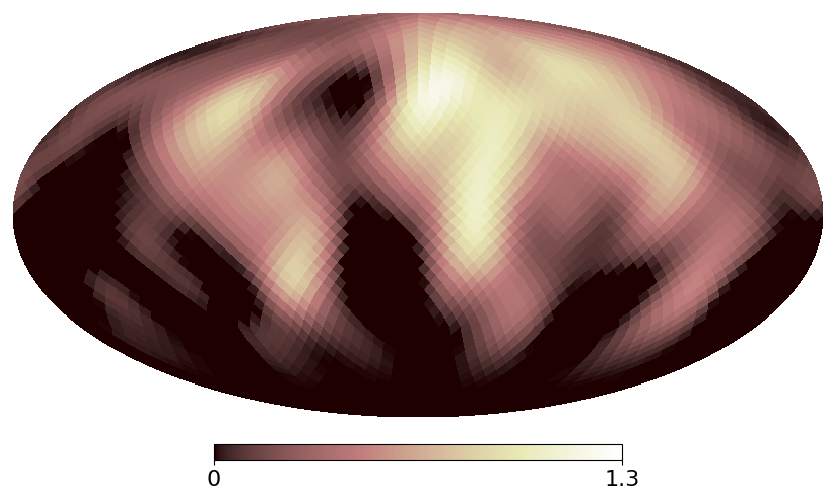

 33%|███▎      | 1/3 [00:00<00:00,  6.40it/s]

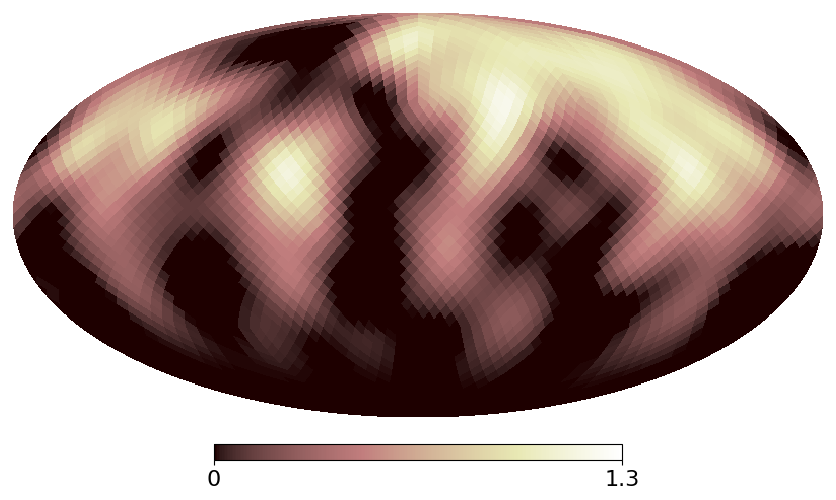

 67%|██████▋   | 2/3 [00:00<00:00,  6.65it/s]

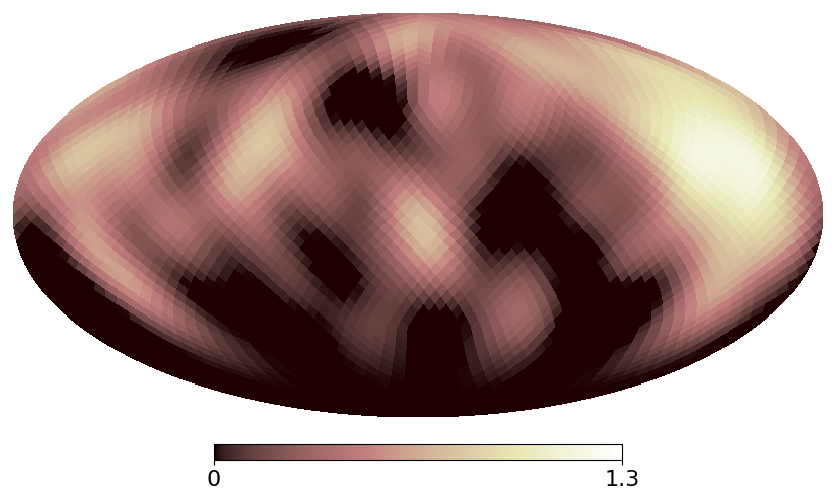

100%|██████████| 3/3 [00:00<00:00,  6.69it/s]


In [23]:
import jax.numpy as jnp
from jaxinv.bayes.gpkernel import rbf
from jaxinv.bayes.gpkernel import matern32
from sot.plot.plotdymap import plotseqmap
from jaxinv.bayes.meanmap import meanmap_inverse_type3

tau = 180.0
gamma = 10.0 / 180.0 * np.pi 
separation_matrix = sepmat.calc_sepmatrix(nside)
KS = rbf(separation_matrix, gamma)

dtime_matrix = obst - np.array([obst]).T
KT = matern32(dtime_matrix, tau)

alpha = 0.25
Pid = jnp.eye(Ni) * sigma**-2 #when using jnp.eye Matrix becomes singular when x32
    
Mast = meanmap_inverse_type3(W, KS, KT, alpha, Pid, lc)
Mast = np.array(Mast)
frames=[0,int(Ni/2),Ni-1]
plotseqmap(Mast,frames,"mapest","",vmin=0.0,vmax=1.3,pdf=False,png=False,show=True)